In [20]:
import numpy as np
import cv2
from matplotlib import pyplot as plt
from skimage.transform import hough_line, hough_line_peaks
import json

from rebar_object_detection import get_bounding_boxes, get_lines, norm_radian

In [21]:
image_path = "data/intersect-detect/test/images/20250620_115012_jpg.rf.239a32ab7bcbefe30fb9f388607d7048.jpg"
model_path = "runs/detect/tune/weights/best.pt"

data = get_lines(image_path, model_path)

In [22]:
image_path = "data/intersect-detect/test/images/20250620_114830_jpg.rf.5e2332d4c667c38b39dfc6d6839eddf1.jpg"
image_path = "data/intersect-detect/test/images/20250620_115012_jpg.rf.239a32ab7bcbefe30fb9f388607d7048.jpg"
model_path = "runs/detect/tune/weights/best.pt"

bounding_boxes = get_bounding_boxes(image_path, model_path)
vertices = []
for box in bounding_boxes:
    x_center = (box[0] + box[2]) / 2
    y_center = (box[1] + box[3]) / 2
    vertices.append((x_center, y_center))
vertices = np.array(vertices)

print(vertices)

[[      163.6      188.58]
 [     458.37      129.82]
 [      461.5       14.04]
 [     78.042      122.55]
 [     52.154      250.08]
 [     281.55      12.397]
 [     453.75      259.06]
 [     192.92      11.795]
 [     141.53      325.67]
 [     102.36      10.019]
 [     555.79      69.078]
 [     348.61      329.01]
 [     152.93      253.75]
 [     375.39      14.173]
 [     555.67      14.274]
 [     258.29      190.35]
 [     558.81      260.76]
 [     460.12      67.825]
 [     173.99      125.27]
 [      557.5      132.56]
 [     64.832      186.66]
 [     560.45      333.94]
 [      184.2      63.058]
 [      275.4      65.128]
 [     456.16      193.22]
 [     267.37      126.97]
 [     91.382      62.584]
 [     355.43      257.92]
 [     250.51      256.03]
 [     557.68      196.05]
 [     371.71      67.456]
 [     453.02      331.73]
 [     241.32      326.73]
 [     360.67      192.39]
 [     499.17      548.07]
 [     13.928      9.2189]
 [     366.02      128.67]
 

Detected lines (rho, theta):
Line: rho=-7.00, theta=-1.55
Line: rho=-323.00, theta=-1.55
Line: rho=-251.00, theta=-1.55
Line: rho=-185.00, theta=-1.55
Line: rho=-122.00, theta=-1.55
Line: rho=-60.00, theta=-1.55


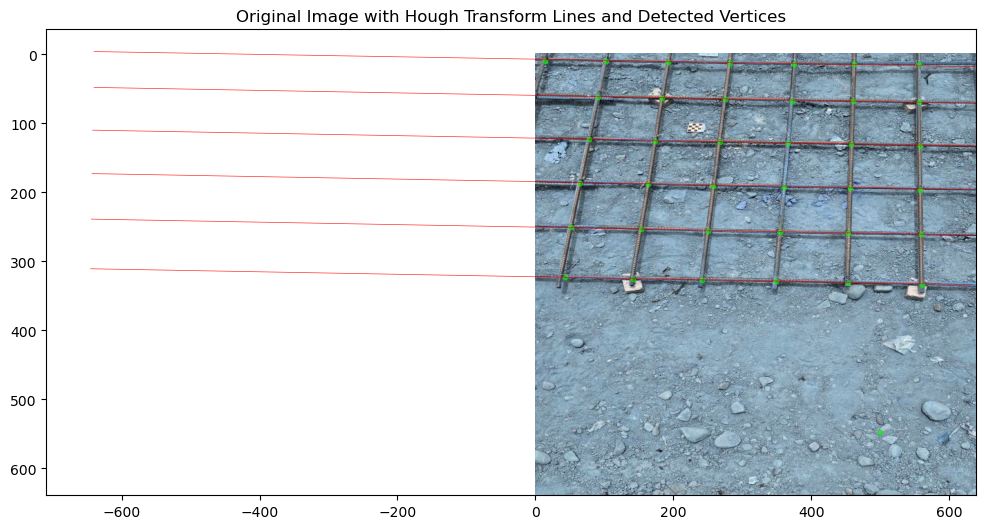

In [27]:
# Load and display the original image
original_image = cv2.imread(image_path)
plt.figure(figsize=(12, 8))
plt.imshow(original_image)

# Get lines data from the model
json_data = get_lines(image_path, model_path, threshold=0)
data = json.loads(json_data)

# Create canvas and draw the lines from get_lines data
height, width = original_image.shape[:2]
canvas = np.zeros((height, width), dtype=np.float32)

# Draw lines on canvas using the get_lines data
for shape in data["shapes"]:
    # if shape["orientation"] == "horizontal":
    if shape["orientation"] == "vertical":
        continue
    points = shape["points"]
    pt1 = (int(points[0][0]), int(points[0][1]))
    pt2 = (int(points[1][0]), int(points[1][1]))
    
    # Draw line on canvas with thickness
    cv2.line(canvas, pt1, pt2, 255, thickness=3)

# Perform Hough Transform
hspace, angles, dists = hough_line(canvas)

# Find peaks
accum, angles_peaks, dists_peaks = hough_line_peaks(hspace, angles, dists, threshold=0.5 * np.max(hspace))

print("Detected lines (rho, theta):")
for rho, theta in zip(dists_peaks, angles_peaks):
    a = np.cos(theta)
    b = np.sin(theta)

    x0 = rho * a
    y0 = rho * b
    
    # Calculate line endpoints
    x1 = int(x0 + width * (-b))
    y1 = int(y0 + height * (a))
    x2 = int(x0 - width * (-b))
    y2 = int(y0 - height * (a))

    # Draw the line on top of the original image
    plt.plot([x1, x2], [y1, y2], '-r', linewidth=0.5, alpha=0.8)
    
    print(f"Line: rho={rho:.2f}, theta={theta:.2f}")

# Also plot the detected vertices
vertices_x = [v[0] for v in vertices]
vertices_y = [v[1] for v in vertices]
plt.scatter(vertices_x, vertices_y, c='lime', s=10, alpha=0.5)

plt.title("Original Image with Hough Transform Lines and Detected Vertices")
plt.show()

In [24]:
angles = []
for theta in angles_peaks:
    angle = norm_radian(theta + np.pi / 2, pi=np.pi)
    angles.append(angle)
angles

[1.5533430342749532,
 1.6057029118347832,
 1.6580627893946132,
 1.7278759594743862,
 1.710422666954443,
 1.7627825445142729,
 1.361356816555577,
 1.8500490071139892,
 1.2915436464758039]

In [25]:
diff = np.ptp(angles)
if diff > np.pi / 2:
    for i in range(len(angles)):
        if angles[i] > np.pi / 2:
            angles[i] = norm_radian(angles[i] + np.pi, pi=np.pi)
angles
min, max = np.min(angles), np.max(angles)

Angle range: [1.292, 1.850] radians
Angle range: [74.0°, 106.0°]
✗ Removing horizontal line: angle=0.021 rad (1.2°)
✗ Removing horizontal line: angle=0.031 rad (1.8°)
✗ Removing horizontal line: angle=0.003 rad (0.2°)
✗ Removing horizontal line: angle=0.032 rad (1.8°)
✗ Removing horizontal line: angle=0.041 rad (2.3°)
✗ Removing horizontal line: angle=0.021 rad (1.2°)
✗ Removing horizontal line: angle=0.018 rad (1.0°)
✗ Removing horizontal line: angle=0.008 rad (0.4°)
✗ Removing horizontal line: angle=0.012 rad (0.7°)
✗ Removing horizontal line: angle=0.022 rad (1.3°)
✗ Removing horizontal line: angle=0.029 rad (1.7°)
✗ Removing horizontal line: angle=0.026 rad (1.5°)
✗ Removing horizontal line: angle=3.140 rad (179.9°)
✗ Removing horizontal line: angle=0.022 rad (1.3°)
✗ Removing horizontal line: angle=0.015 rad (0.8°)
✗ Removing horizontal line: angle=0.020 rad (1.2°)
✗ Removing horizontal line: angle=0.022 rad (1.3°)
✗ Removing horizontal line: angle=0.026 rad (1.5°)
✗ Removing hori

TypeError: 'numpy.float64' object is not callable

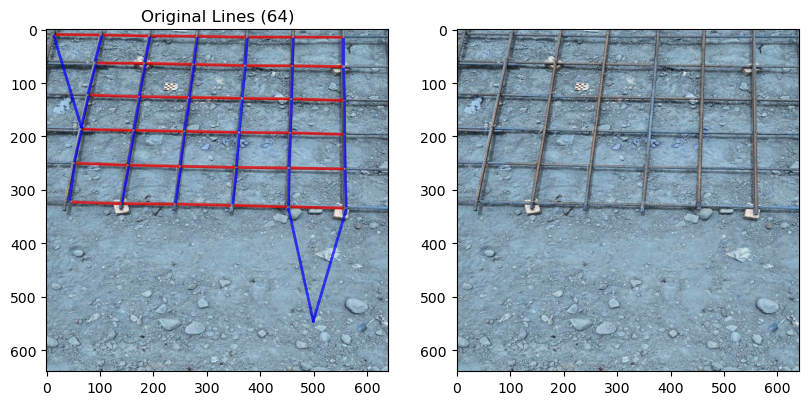

In [26]:
def get_line_angle(pt1, pt2):
    """Get the angle of a line segment in radians"""
    x1, y1 = pt1
    x2, y2 = pt2
    return np.arctan2(y2 - y1, x2 - x1)

def normalize_angle_to_hough_range(angle):
    """Normalize angle to match Hough Transform range [0, π]"""
    # Convert to [0, 2π] range first
    angle = angle % (2 * np.pi)
    # Convert to [0, π] range (since θ and θ+π represent same line)
    if angle > np.pi:
        angle -= np.pi
    return angle

# Get the min and max from your processed angles
angle_min, angle_max = min, max  # From your previous cell

print(f"Angle range: [{angle_min:.3f}, {angle_max:.3f}] radians")
print(f"Angle range: [{np.degrees(angle_min):.1f}°, {np.degrees(angle_max):.1f}°]")

# Get lines data from the model
json_data = get_lines(image_path, model_path)
data = json.loads(json_data)

# Filter lines based on angle range
filtered_shapes = []
removed_shapes = []

for shape in data["shapes"]:
    points = shape["points"]
    pt1 = (points[0][0], points[0][1])
    pt2 = (points[1][0], points[1][1])
    
    # Get the angle of this line
    line_angle = get_line_angle(pt1, pt2)
    
    # Normalize to same range as your Hough angles
    normalized_angle = normalize_angle_to_hough_range(line_angle)
    
    # Check if angle is within the range
    if angle_min <= normalized_angle <= angle_max:
        filtered_shapes.append(shape)
        print(f"✓ Keeping {shape['orientation']} line: angle={normalized_angle:.3f} rad ({np.degrees(normalized_angle):.1f}°)")
    else:
        removed_shapes.append(shape)
        print(f"✗ Removing {shape['orientation']} line: angle={normalized_angle:.3f} rad ({np.degrees(normalized_angle):.1f}°)")

print(f"\nSummary: Kept {len(filtered_shapes)} lines, removed {len(removed_shapes)} lines")

# Visualize the results
plt.figure(figsize=(15, 5))

# Original lines
plt.subplot(1, 3, 1)
plt.imshow(original_image)
for shape in data["shapes"]:
    points = shape["points"]
    color = 'red' if shape["orientation"] == "horizontal" else 'blue'
    plt.plot([points[0][0], points[1][0]], [points[0][1], points[1][1]], 
             color=color, linewidth=2, alpha=0.7)
plt.title(f"Original Lines ({len(data['shapes'])})")

# Show angle range as reference
plt.subplot(1, 3, 2)
plt.imshow(original_image)
# Draw lines representing the min/max angle range
height, width = original_image.shape[:2]
center_x, center_y = width//2, height//2
line_length = min(width, height) // 2

for angle in [angle_min, angle_max]:
    x1 = center_x
    y1 = center_y
    x2 = int(center_x + line_length * np.cos(angle))
    y2 = int(center_y + line_length * np.sin(angle))
    plt.plot([x1, x2], [y1, y2], 'orange', linewidth=3, alpha=0.8)

plt.title(f"Angle Range [{np.degrees(angle_min):.1f}°, {np.degrees(angle_max):.1f}°]")

# Filtered lines
plt.subplot(1, 3, 3)
plt.imshow(original_image)
for shape in filtered_shapes:
    points = shape["points"]
    color = 'red' if shape["orientation"] == "horizontal" else 'blue'
    plt.plot([points[0][0], points[1][0]], [points[0][1], points[1][1]], 
             color=color, linewidth=2, alpha=0.7)
plt.title(f"Filtered Lines ({len(filtered_shapes)})")

plt.tight_layout()
plt.show()

# Update your data with filtered shapes
filtered_data = {"shapes": filtered_shapes}

In [ ]:
from scipy.stats import circmean, circstd

# Convert angles_peaks (which are already in radians) to degrees and find min/max
angles_degrees = np.degrees(angles_peaks)
angles_radians = angles_peaks  # These are already in radians

angles_radians = [2 * radian for radian in angles_radians]
mean = circmean(angles_radians, high=np.pi, low=-np.pi)
deltas = [norm_radian(radian - mean) for radian in angles_radians]
maxdelta = 2 * circstd(angles_radians, high=np.pi, low=-np.pi)

print("Deltas: ", deltas)
print(maxdelta)

print("Angles in radians:")
print(f"angles_peaks: {angles_radians}")
print(f"Min angle: {np.min(angles_radians):.3f} radians ({np.degrees(np.min(angles_radians)):.1f}°)")
print(f"Max angle: {np.max(angles_radians):.3f} radians ({np.degrees(np.max(angles_radians)):.1f}°)")
print(f"Range: {np.max(angles_radians) - np.min(angles_radians):.3f} radians ({np.degrees(np.max(angles_radians) - np.min(angles_radians)):.1f}°)")

print("\nAngles in degrees:")
print(f"angles_degrees: {angles_degrees}")
print(f"Min angle: {np.min(angles_degrees):.1f}°")
print(f"Max angle: {np.max(angles_degrees):.1f}°")

Deltas:  [-0.04564598830214983, -0.04564598830214983, -0.010739403262263636, -0.04564598830214983, 0.024167181777623448, -0.010739403262263636, -0.04564598830214983, 0.024167181777623448, -0.010739403262263636, 0.05907376681751009, 0.024167181777623448, 0.024167181777623448, 0.05907376681751009]
0.07441772894880039
Angles in radians:
angles_peaks: [3.106686068549907, 3.106686068549907, -3.141592653589793, 3.106686068549907, -3.1066860685499065, -3.141592653589793, 3.106686068549907, -3.1066860685499065, -3.141592653589793, -3.07177948351002, -3.1066860685499065, -3.1066860685499065, -3.07177948351002]
Min angle: -3.142 radians (-180.0°)
Max angle: 3.107 radians (178.0°)
Range: 6.248 radians (358.0°)

Angles in degrees:
angles_degrees: [         89          89         -90          89         -89         -90          89         -89         -90         -88         -89         -89         -88]
Min angle: -90.0°
Max angle: 89.0°


In [ ]:
def get_line_angle(pt1, pt2):
    """Get the angle of a line segment in radians"""
    x1, y1 = pt1
    x2, y2 = pt2
    return np.arctan2(y2 - y1, x2 - x1)

def normalize_angle(angle):
    """Normalize angle to [-π, π]"""
    return ((angle + np.pi) % (2*np.pi)) - np.pi

def angle_is_similar(angle1, angle2, tolerance=0.15):
    """Check if two angles are similar, considering π periodicity for lines"""
    # Normalize both angles
    angle1 = normalize_angle(angle1)
    angle2 = normalize_angle(angle2)
    
    # Calculate minimum angle difference (considering π periodicity for lines)
    diff = min(
        abs(angle1 - angle2),
        abs(angle1 - angle2 + np.pi),
        abs(angle1 - angle2 - np.pi)
    )
    
    return diff < tolerance

json_data = get_lines(image_path, model_path)
data = json.loads(json_data)

# Create canvas and draw the lines from get_lines data
height, width = original_image.shape[:2]
canvas = np.zeros((height, width), dtype=np.float32)

# Draw lines on canvas using the get_lines data
for shape in data["shapes"]:
    if shape["orientation"] == "horizontal":
        continue
    points = shape["points"]
    pt1 = (int(points[0][0]), int(points[0][1]))
    pt2 = (int(points[1][0]), int(points[1][1]))
    
    # Draw line on canvas with thickness
    cv2.line(canvas, pt1, pt2, 255, thickness=3)

# Perform Hough Transform
hspace, angles, dists = hough_line(canvas)
accum, angles_peaks, dists_peaks = hough_line_peaks(hspace, angles, dists, threshold=0.5 * np.max(hspace))

print("Hough Transform detected angles:")
hough_thetas = angles_peaks
for i, theta in enumerate(hough_thetas):
    print(f"Hough Angle {i+1}: {theta:.3f} rad ({np.degrees(theta):.1f}°)")

# Filter lines based on angle similarity to Hough thetas
filtered_shapes = []
removed_shapes = []

angle_tolerance = 0.15  # ~8.6 degrees

for shape in data["shapes"]:
    points = shape["points"]
    pt1 = (points[0][0], points[0][1])
    pt2 = (points[1][0], points[1][1])
    
    # Get the angle of this line
    line_angle = get_line_angle(pt1, pt2)
    
    # Check if this angle matches any Hough-detected angle
    is_aligned = False
    for hough_theta in hough_thetas:
        if angle_is_similar(line_angle, hough_theta, angle_tolerance):
            is_aligned = True
            break
    
    if is_aligned:
        filtered_shapes.append(shape)
        print(f"✓ Keeping {shape['orientation']} line: angle={line_angle:.3f} rad ({np.degrees(line_angle):.1f}°)")
    else:
        removed_shapes.append(shape)
        print(f"✗ Removing {shape['orientation']} line: angle={line_angle:.3f} rad ({np.degrees(line_angle):.1f}°)")

print(f"\nSummary: Kept {len(filtered_shapes)} lines, removed {len(removed_shapes)} lines")

# Visualize the results
plt.figure(figsize=(15, 5))

# Original lines
plt.subplot(1, 3, 1)
plt.imshow(original_image)
for shape in data["shapes"]:
    points = shape["points"]
    color = 'red' if shape["orientation"] == "horizontal" else 'blue'
    plt.plot([points[0][0], points[1][0]], [points[0][1], points[1][1]], 
             color=color, linewidth=2, alpha=0.7)
plt.title(f"Original Lines ({len(data['shapes'])})")

# Hough Transform lines (for reference)
plt.subplot(1, 3, 2)
plt.imshow(original_image)
for rho, theta in zip(dists_peaks, angles_peaks):
    a, b = np.cos(theta), np.sin(theta)
    x0, y0 = rho * a, rho * b
    x1 = int(x0 + width * (-b))
    y1 = int(y0 + height * (a))
    x2 = int(x0 - width * (-b))
    y2 = int(y0 - height * (a))
    plt.plot([x1, x2], [y1, y2], 'green', linewidth=2, alpha=0.7)
plt.title(f"Hough Reference Lines ({len(dists_peaks)})")

# Filtered lines (angle-pruned)
plt.subplot(1, 3, 3)
plt.imshow(original_image)
for shape in filtered_shapes:
    if shape["orientation"] == "horizontal":
        continue
    points = shape["points"]
    color = 'red' if shape["orientation"] == "horizontal" else 'blue'
    plt.plot([points[0][0], points[1][0]], [points[0][1], points[1][1]], 
             color=color, linewidth=2, alpha=0.7)
plt.title(f"Angle-Filtered Lines ({len(filtered_shapes)})")

plt.tight_layout()
plt.show()

# Update your data with angle-filtered shapes
filtered_data = {"shapes": filtered_shapes}

Hough Transform detected angles:
Hough Angle 1: 0.175 rad (10.0°)
Hough Angle 2: -0.297 rad (-17.0°)
Hough Angle 3: 0.017 rad (1.0°)
Hough Angle 4: -0.052 rad (-3.0°)
Hough Angle 5: -0.140 rad (-8.0°)
Hough Angle 6: 0.105 rad (6.0°)
Hough Angle 7: -0.227 rad (-13.0°)
Hough Angle 8: -0.349 rad (-20.0°)


TypeError: 'numpy.float64' object is not callable

Hough Transform detected lines:
Hough Line 1: rho=470.00, theta=1.553 (89.0°)
Hough Line 2: rho=419.00, theta=1.553 (89.0°)
Hough Line 3: rho=-362.00, theta=-1.571 (-90.0°)
Hough Line 4: rho=-198.00, theta=-1.553 (-89.0°)
Hough Line 5: rho=532.00, theta=1.553 (89.0°)
Hough Line 6: rho=101.00, theta=0.175 (10.0°)
Hough Line 7: rho=400.00, theta=-0.297 (-17.0°)
Hough Line 8: rho=-279.00, theta=-1.571 (-90.0°)
Hough Line 9: rho=215.00, theta=0.017 (1.0°)
Hough Line 10: rho=269.00, theta=-0.052 (-3.0°)
Hough Line 11: rho=324.00, theta=1.553 (89.0°)
Hough Line 12: rho=-166.00, theta=-1.553 (-89.0°)
Hough Line 13: rho=317.00, theta=-0.140 (-8.0°)
Hough Line 14: rho=160.00, theta=0.105 (6.0°)
Hough Line 15: rho=358.00, theta=-0.227 (-13.0°)
Hough Line 16: rho=-240.00, theta=-1.571 (-90.0°)
Hough Line 17: rho=442.00, theta=-0.349 (-20.0°)
Hough Line 18: rho=-12.00, theta=-1.536 (-88.0°)
Hough Line 19: rho=-109.00, theta=-1.553 (-89.0°)
Hough Line 20: rho=-136.00, theta=-1.553 (-89.0°)
Hough Li

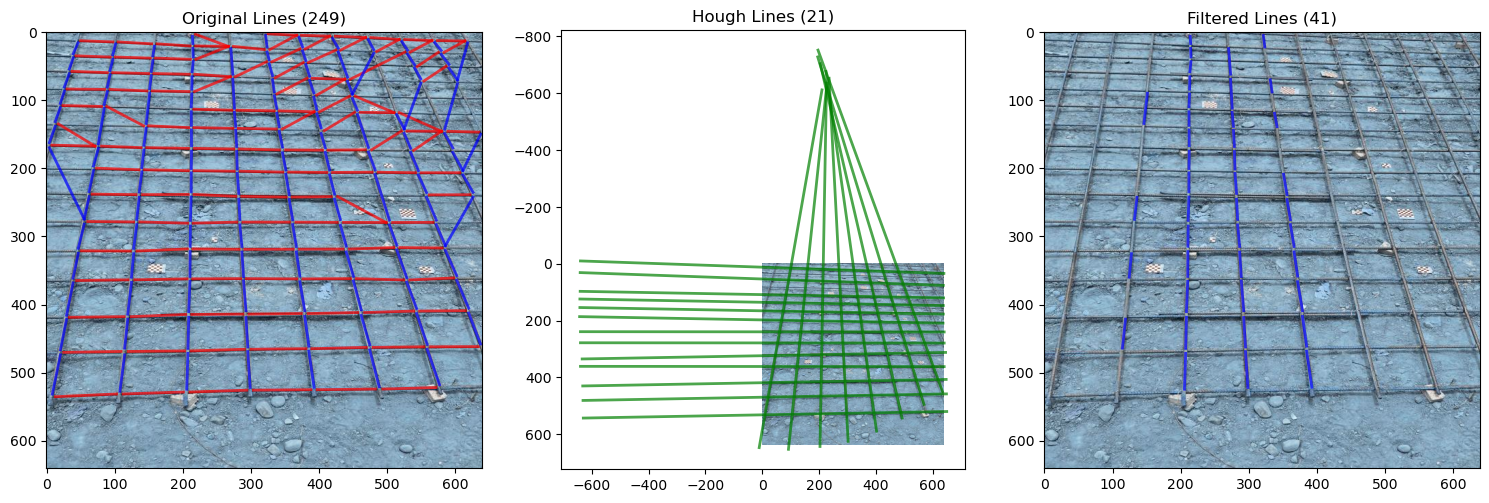

In [ ]:
def line_to_rho_theta(pt1, pt2):
    """Convert line segment to rho-theta representation"""
    x1, y1 = pt1
    x2, y2 = pt2
    
    # Calculate line parameters ax + by + c = 0
    if x2 - x1 == 0:  # Vertical line
        rho = abs(x1)
        theta = np.pi/2 if x1 >= 0 else -np.pi/2
    else:
        # Calculate slope and intercept
        m = (y2 - y1) / (x2 - x1)
        b = y1 - m * x1
        
        # Convert to ax + by + c = 0 form: mx - y + b = 0
        # Normalize: a = m/sqrt(m²+1), b = -1/sqrt(m²+1), c = b/sqrt(m²+1)
        norm = np.sqrt(m*m + 1)
        a = m / norm
        b = -1 / norm
        c = b / norm
        
        # rho-theta form: x*cos(theta) + y*sin(theta) = rho
        theta = np.arctan2(-a, -b)  # angle of normal vector
        rho = -c  # distance from origin
    
    return rho, theta

def lines_are_similar(rho1, theta1, rho2, theta2, rho_tolerance=30, theta_tolerance=0.1):
    """Check if two lines (in rho-theta form) are similar"""
    # Normalize angles to [-π, π]
    theta1 = ((theta1 + np.pi) % (2*np.pi)) - np.pi
    theta2 = ((theta2 + np.pi) % (2*np.pi)) - np.pi
    
    # Check angle difference (considering π periodicity for lines)
    angle_diff = min(abs(theta1 - theta2), abs(theta1 - theta2 + np.pi), abs(theta1 - theta2 - np.pi))
    
    # Check distance difference
    rho_diff = abs(rho1 - rho2)
    
    return angle_diff < theta_tolerance and rho_diff < rho_tolerance

# Your existing code...
json_data = get_lines(image_path, model_path)
data = json.loads(json_data)

# Create canvas and draw lines
height, width = original_image.shape[:2]
canvas = np.zeros((height, width), dtype=np.uint8)

for shape in data["shapes"]:
    points = shape["points"]
    pt1 = (int(points[0][0]), int(points[0][1]))
    pt2 = (int(points[1][0]), int(points[1][1]))
    cv2.line(canvas, pt1, pt2, 255, thickness=3)

# Perform Hough Transform
hspace, angles, dists = hough_line(canvas)
accum, angles_peaks, dists_peaks = hough_line_peaks(hspace, angles, dists, threshold=0.5 * np.max(hspace))

print("Hough Transform detected lines:")
for i, (rho, theta) in enumerate(zip(dists_peaks, angles_peaks)):
    print(f"Hough Line {i+1}: rho={rho:.2f}, theta={theta:.3f} ({np.degrees(theta):.1f}°)")

# Convert data["shapes"] lines to rho-theta and compare
filtered_shapes = []
removed_shapes = []

for shape in data["shapes"]:
    points = shape["points"]
    pt1 = (points[0][0], points[0][1])
    pt2 = (points[1][0], points[1][1])
    
    # Convert to rho-theta
    shape_rho, shape_theta = line_to_rho_theta(pt1, pt2)
    
    # Check if this line matches any Hough line
    is_aligned = False
    for hough_rho, hough_theta in zip(dists_peaks, angles_peaks):
        if lines_are_similar(shape_rho, shape_theta, hough_rho, hough_theta, 
                           rho_tolerance=30, theta_tolerance=0.15):  # ~8.6 degrees
            is_aligned = True
            break
    
    if is_aligned:
        filtered_shapes.append(shape)
        print(f"✓ Keeping {shape['orientation']} line: rho={shape_rho:.2f}, theta={shape_theta:.3f}")
    else:
        removed_shapes.append(shape)
        print(f"✗ Removing {shape['orientation']} line: rho={shape_rho:.2f}, theta={shape_theta:.3f}")

print(f"\nSummary: Kept {len(filtered_shapes)} lines, removed {len(removed_shapes)} lines")

# Visualize the results
plt.figure(figsize=(15, 5))

# Original lines
plt.subplot(1, 3, 1)
plt.imshow(original_image)
for shape in data["shapes"]:
    points = shape["points"]
    color = 'red' if shape["orientation"] == "horizontal" else 'blue'
    plt.plot([points[0][0], points[1][0]], [points[0][1], points[1][1]], 
             color=color, linewidth=2, alpha=0.7)
plt.title(f"Original Lines ({len(data['shapes'])})")

# Hough Transform lines
plt.subplot(1, 3, 2)
plt.imshow(original_image)
for rho, theta in zip(dists_peaks, angles_peaks):
    a, b = np.cos(theta), np.sin(theta)
    x0, y0 = rho * a, rho * b
    x1 = int(x0 + width * (-b))
    y1 = int(y0 + height * (a))
    x2 = int(x0 - width * (-b))
    y2 = int(y0 - height * (a))
    plt.plot([x1, x2], [y1, y2], 'green', linewidth=2, alpha=0.7)
plt.title(f"Hough Lines ({len(dists_peaks)})")

# Filtered lines
plt.subplot(1, 3, 3)
plt.imshow(original_image)
for shape in filtered_shapes:
    points = shape["points"]
    color = 'red' if shape["orientation"] == "horizontal" else 'blue'
    plt.plot([points[0][0], points[1][0]], [points[0][1], points[1][1]], 
             color=color, linewidth=2, alpha=0.7)
plt.title(f"Filtered Lines ({len(filtered_shapes)})")

plt.tight_layout()
plt.show()

# Update your data with filtered shapes
filtered_data = {"shapes": filtered_shapes}